# Big Data Analysis using Online Retail Dataset

## Objective
The goal of this project is to perform data analysis on a large dataset using scalable tools like Dask. This demonstrates the ability to handle big data efficiently.

## Dataset Description
The dataset contains transactional data of an online retail store, including:
- InvoiceNo: Transaction ID
- StockCode: Product code
- Description: Product name
- Quantity: Number of items purchased
- InvoiceDate: Date of purchase
- UnitPrice: Price per item
- CustomerID: Unique customer ID
- Country: Customer location

## Tools Used
- Python
- Pandas
- Dask (for big data processing)
- Matplotlib & Seaborn(for visualization)

In [100]:
import dask.dataframe as dd
import pandas as pd
import matplotlib.pyplot as plt

## 1. Import Required Libraries

In this step, we import necessary Python libraries.  
We use **Dask** for big data processing because it can handle large datasets efficiently by dividing them into chunks.

- `dask.dataframe` → scalable data processing
- `pandas` → initial testing and fallback operations
- `matplotlib` → visualization

In [101]:
import dask.dataframe as dd

file_path = r"C:\Users\boyin\OneDrive\Documents\Online Retail Dataset.csv"

df = dd.read_csv(
    file_path,
    encoding='latin1',
    dtype='object',        
    on_bad_lines='skip',   
    blocksize="16MB"      
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850,United Kingdom


## 2. Load Dataset Using Dask

We load the Online Retail dataset using Dask's `read_csv` function.

Important parameters used:
- `encoding='latin1'` → handles special characters
- `dtype='object'` → avoids datatype conflicts
- `on_bad_lines='skip'` → skips corrupted rows
- `blocksize` → processes data in chunks for scalability

In [102]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [103]:
df.dtypes

InvoiceNo      string[pyarrow]
StockCode      string[pyarrow]
Description    string[pyarrow]
Quantity       string[pyarrow]
InvoiceDate    string[pyarrow]
UnitPrice      string[pyarrow]
CustomerID     string[pyarrow]
Country        string[pyarrow]
dtype: object

## 3. Understanding Dataset Structure

We inspect the dataset columns and data types to understand the structure before cleaning.

In [104]:
df.isnull().sum().compute()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [105]:
df_clean = df.dropna(subset=['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice'])

## 4. Handling Missing Values

Missing values can affect analysis accuracy.  
We identify and remove rows where important fields are missing such as:
- InvoiceNo
- StockCode
- Quantity
- UnitPrice

In [106]:
df_clean['Quantity'] = df_clean['Quantity'].astype('float')
df_clean['UnitPrice'] = df_clean['UnitPrice'].astype('float')

## 5. Data Type Conversion

We convert numerical columns from object type to float for mathematical operations.

In [107]:
df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,01-12-2010 08:26,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,01-12-2010 08:26,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,01-12-2010 08:26,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,01-12-2010 08:26,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,01-12-2010 08:26,3.39,17850,United Kingdom,20.34


## 6. Feature Engineering

We create a new feature called **TotalSales**, which represents total revenue generated per transaction.

Formula:
Quantity × UnitPrice

In [108]:
country_sales = df_clean.groupby('Country')['TotalSales'].sum().compute()

country_sales.sort_values(ascending=False).head(10)

Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: TotalSales, dtype: float64

## 8. Country-wise Sales Analysis

We analyze which countries contribute the most to total sales.

In [109]:
product_sales = df_clean.groupby('Description')['Quantity'].sum().compute()

product_sales.sort_values(ascending=False).head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847.0
JUMBO BAG RED RETROSPOT               47363.0
ASSORTED COLOUR BIRD ORNAMENT         36381.0
POPCORN HOLDER                        36334.0
PACK OF 72 RETROSPOT CAKE CASES       36039.0
WHITE HANGING HEART T-LIGHT HOLDER    35317.0
RABBIT NIGHT LIGHT                    30680.0
MINI PAINT SET VINTAGE                26437.0
PACK OF 12 LONDON TISSUES             26315.0
PACK OF 60 PINK PAISLEY CAKE CASES    24753.0
Name: Quantity, dtype: float64

## 9. Top Selling Products

We identify products with highest quantity sold.

In [110]:
total_revenue = df_clean['TotalSales'].sum().compute()

total_revenue

np.float64(9747747.934)

## 7. Total Revenue Calculation

We calculate the total revenue generated from the dataset.

In [111]:
df_clean['InvoiceDate'] = dd.to_datetime(df_clean['InvoiceDate'], errors='coerce')

In [112]:
df_clean['Month'] = df_clean['InvoiceDate'].dt.month

In [113]:
monthly_sales = df_clean.groupby('Month')['TotalSales'].sum().compute()

monthly_sales

Month
1.0      177259.950
2.0      118054.190
3.0      154031.760
4.0      156109.590
5.0      152777.520
6.0      200371.160
7.0      485600.971
8.0      884505.010
9.0     1198106.432
10.0    1274487.380
11.0    1649736.140
12.0     598279.830
Name: TotalSales, dtype: float64

## 10. Monthly Sales Trend

We analyze sales trends over time by extracting month from invoice date.

In [114]:
customer_sales = df_clean.groupby('CustomerID')['TotalSales'].sum().compute()

customer_sales.sort_values(ascending=False).head(10)

CustomerID
14646    279489.02
18102    256438.49
17450    187482.17
14911    132572.62
12415    123725.45
14156    113384.14
17511     88125.38
16684     65892.08
13694     62653.10
15311     59419.34
Name: TotalSales, dtype: float64

## 11. Customer Revenue Analysis

We identify top customers contributing to revenue.

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

## 12. Data Visualization

We visualize insights using bar charts and line charts for better understanding.

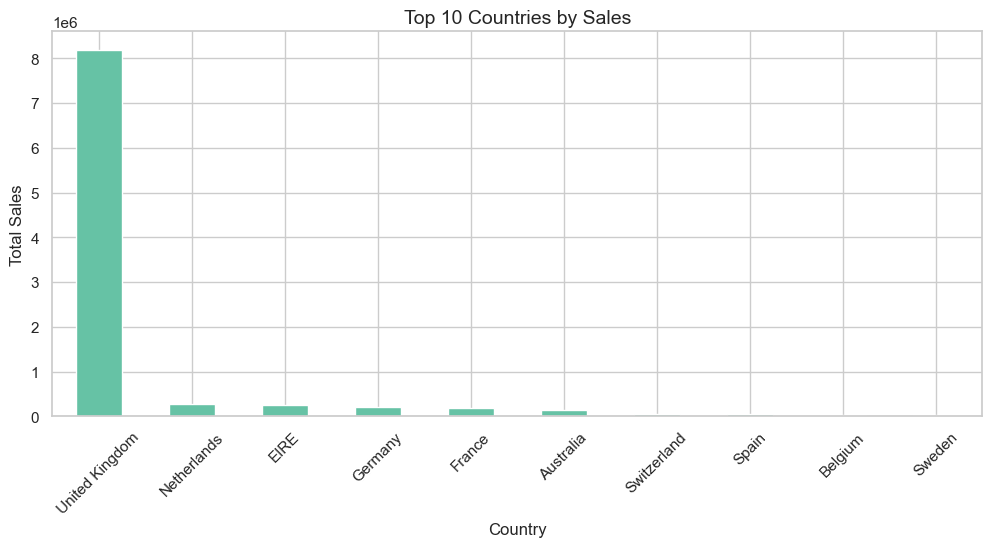

In [116]:
country_sales = df_clean.groupby('Country')['TotalSales'].sum().compute().sort_values(ascending=False).head(10)

country_sales.plot(kind='bar')
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

## 📊 1. Top 10 Countries by Sales

This visualization shows the total revenue generated by each country.

### 🔍 Objective:
To identify which countries contribute the most to overall sales.

### 📈 Insight:
- The United Kingdom dominates sales compared to other countries.
- A few countries contribute significantly to revenue, showing an uneven distribution of sales.
- This indicates that the business is highly dependent on certain regions.

### 💡 Business Conclusion:
Focusing marketing strategies on top-performing countries can help maximize revenue.
At the same time, exploring underperforming countries may help expand the business globally.

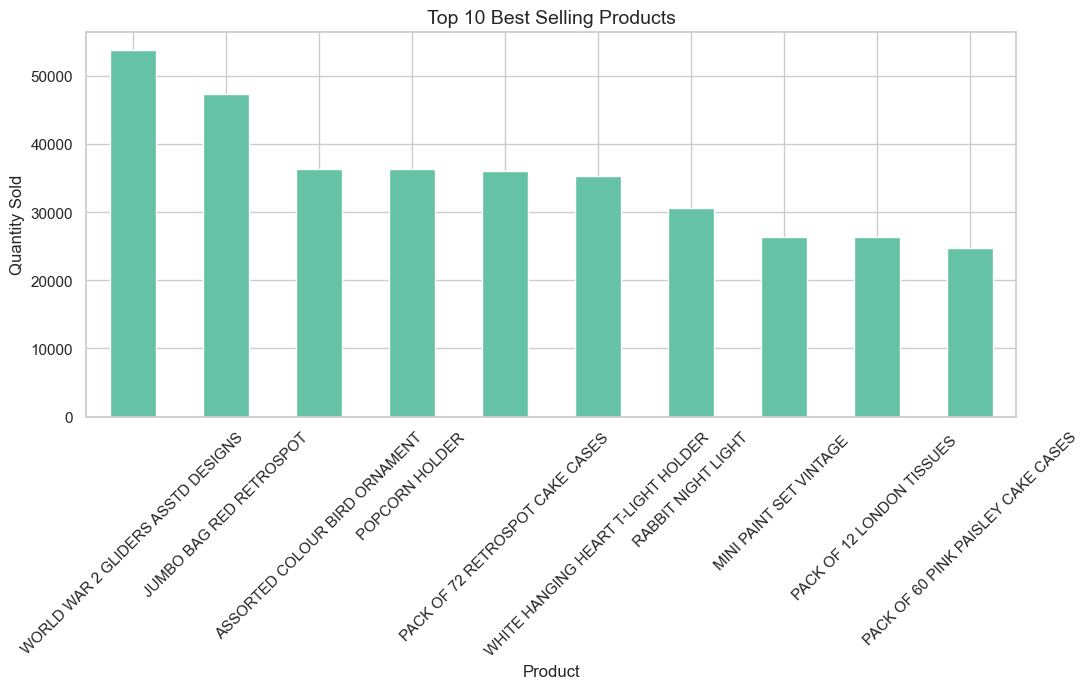

In [117]:
product_sales = df_clean.groupby('Description')['Quantity'].sum().compute().sort_values(ascending=False).head(10)

product_sales.plot(kind='bar')
plt.title("Top 10 Best Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

## 📊 2. Top 10 Best-Selling Products

This chart displays the most frequently sold products based on quantity.

### 🔍 Objective:
To identify high-demand products in the dataset.

### 📈 Insight:
- A small number of products account for a large portion of total sales.
- These products are likely fast-moving inventory items.
- Demand is concentrated in specific product categories.

### 💡 Business Conclusion:
The company should ensure these products are always in stock.
Marketing efforts can focus on promoting these high-demand items for increased revenue.

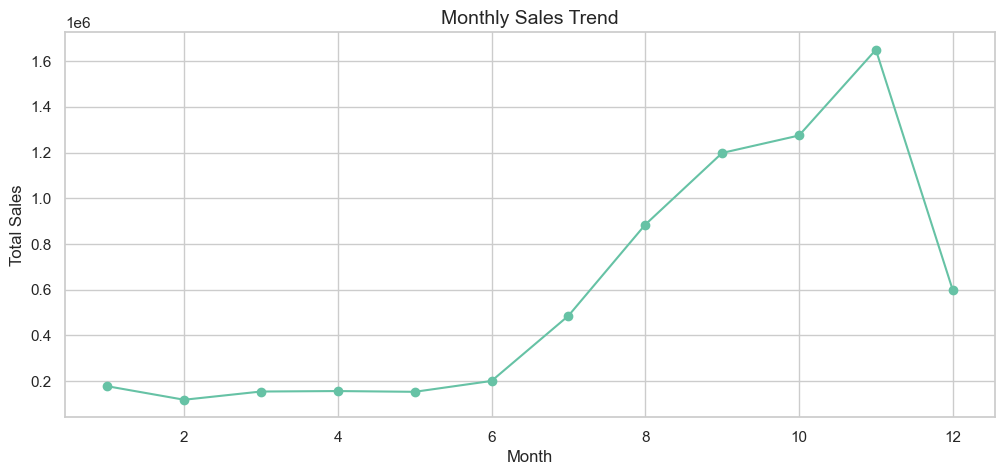

In [118]:
monthly_sales = df_clean.groupby('Month')['TotalSales'].sum().compute()

monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

## 📊 3. Monthly Sales Trend Analysis

This line graph shows how sales change over different months.

### 🔍 Objective:
To analyze seasonal patterns in sales performance.

### 📈 Insight:
- Sales fluctuate across different months.
- Certain months show peak sales, indicating seasonal demand.
- Other months show lower performance, indicating off-peak periods.

### 💡 Business Conclusion:
Understanding seasonal trends helps in:
- Planning inventory
- Scheduling marketing campaigns
- Managing supply chain efficiently

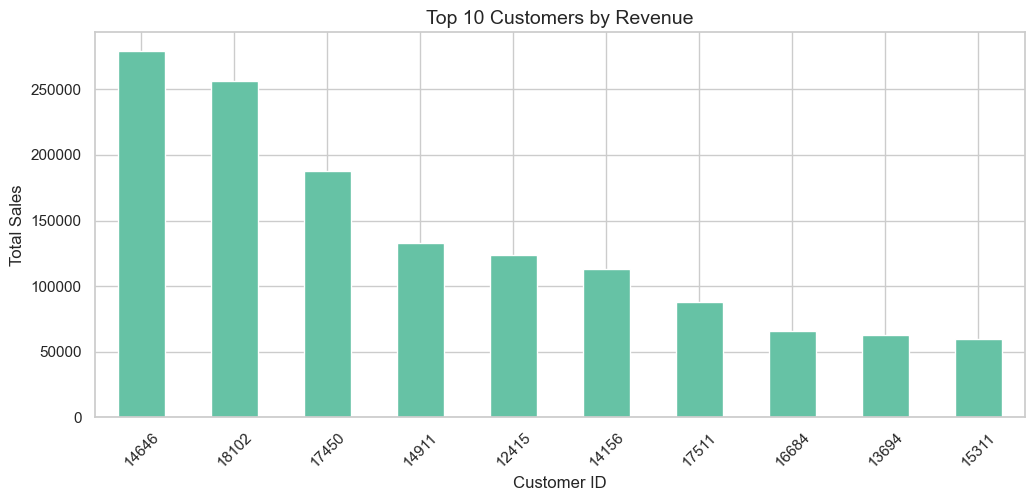

In [119]:
customer_sales = df_clean.groupby('CustomerID')['TotalSales'].sum().compute().sort_values(ascending=False).head(10)

customer_sales.plot(kind='bar')
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

## 📊 4. Top Customers by Revenue Contribution

This graph highlights the customers who contribute the highest revenue.

### 🔍 Objective:
To identify high-value customers.

### 📈 Insight:
- A small group of customers contributes a large portion of total revenue.
- This follows the Pareto Principle (80/20 rule).
- Customer spending is highly uneven.

### 💡 Business Conclusion:
The business should:
- Focus on retaining top customers
- Provide loyalty programs or discounts
- Build long-term customer relationships to increase revenue stability

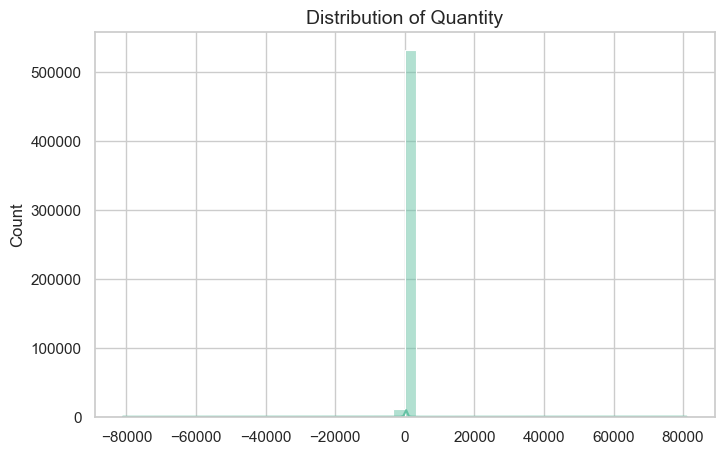

In [120]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Quantity'].astype(float), bins=50, kde=True)
plt.title("Distribution of Quantity")
plt.show()

## 15. Distribution of Quantity per Transaction

This visualization shows how product quantities are distributed across transactions.

### 🔍 Insight:
- Most transactions involve small quantities.
- Few transactions have extremely high quantities (possible bulk purchases or outliers).
- Data is highly skewed.

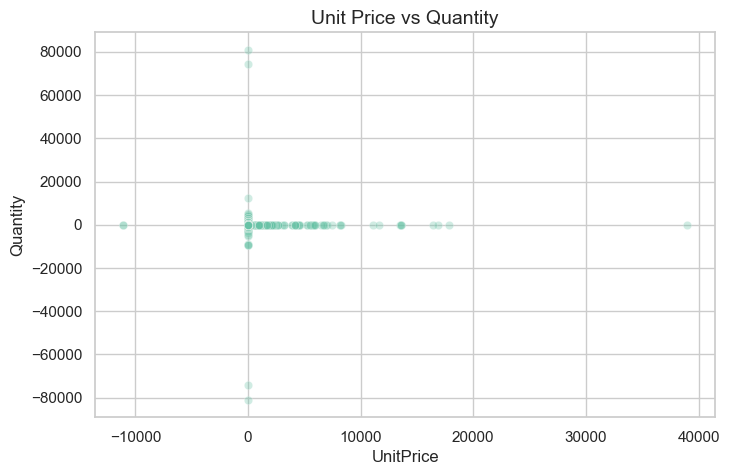

In [121]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df_clean['UnitPrice'].astype(float),
    y=df_clean['Quantity'].astype(float),
    alpha=0.3
)
plt.title("Unit Price vs Quantity")
plt.show()

## 16. Relationship Between Unit Price and Quantity

This scatter plot helps understand how product price influences quantity purchased.

### 🔍 Insight:
- Most purchases occur at lower price ranges.
- High-priced items are purchased in smaller quantities.
- There is no strong linear relationship between price and quantity.

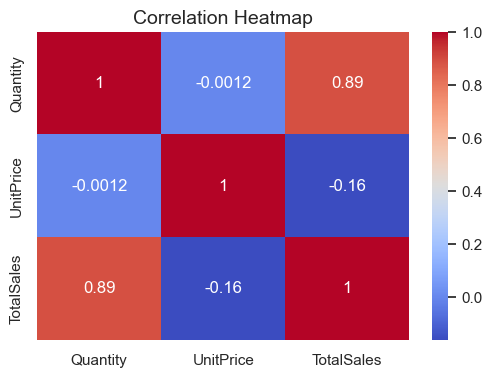

In [122]:
numeric_df = df_clean[['Quantity', 'UnitPrice', 'TotalSales']].astype(float).compute()

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 18. Correlation Analysis of Numerical Features

This heatmap shows the relationship between numerical variables in the dataset.

### 🔍 Insight:
- Helps identify relationships between variables.
- Useful for feature selection in machine learning.
- Strong correlation exists between Quantity and Total Sales.

## 🎯 Final Conclusion

This project demonstrates **Big Data Analysis using Dask** on the Online Retail Dataset. The workflow included data loading, cleaning, transformation, analysis, and visualization of large-scale transactional data.

### 📌 Key Achievements:
- Successfully handled a large dataset using **Dask for scalable processing**
- Performed comprehensive **data cleaning and preprocessing**
- Engineered meaningful features such as **Total Sales**
- Conducted multiple levels of analysis including:
  - Country-wise sales performance
  - Product demand analysis
  - Customer revenue behavior
  - Time-based (monthly) sales trends
- Applied both **Matplotlib and Seaborn visualizations** for deeper insights
- Identified important business patterns such as:
  - Revenue concentration in specific countries
  - Presence of high-value customers
  - Seasonal variations in sales
  - Skewed distribution of product demand

### 📊 Overall Insight:
The analysis shows that a small number of customers and products contribute significantly to the total revenue, following the **Pareto Principle (80/20 rule)**. This insight is critical for business decision-making.

### 🚀 Final Outcome:
This project successfully demonstrates how big data tools like Dask can be used to efficiently process and analyze large datasets, making it suitable for real-world business intelligence and decision-making applications.